In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


## Bước 1: Load Data & Feature Engineering

### 1.1 Load data 

In [3]:
# Load data
sales = pd.read_csv('../data/raw/sales.csv', parse_dates=['Date'])
sales_test = pd.read_csv('../data/raw/sample_submission.csv', parse_dates=['Date'])

promo = pd.read_csv('../data/raw/promotions.csv', parse_dates=['start_date', 'end_date'])
traffic = pd.read_csv('../data/raw/web_traffic.csv', parse_dates=['date'])
inventory = pd.read_csv('../data/raw/inventory.csv', parse_dates=['snapshot_date'])

sales['is_train'] = 1
sales_test['is_train'] = 0
sales_test['Revenue'] = np.nan
sales_test['COGS'] = np.nan

df = pd.concat([sales, sales_test], ignore_index=True).sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)


### 1.2 Feature engineering

#### a. Calendar/Time Features

In [4]:
# 1.1 Calendar/Time Features
def create_time_features(data):
    df = data.copy()
    df['DayOfWeek'] = df.index.dayofweek
    df['Month'] = df.index.month
    df['Quarter'] = df.index.quarter
    df['Is_Weekend'] = np.where(df.index.dayofweek >= 5, 1, 0)
    
    # Vietnam Holidays Proxy (Lễ/Tết)
    df['Is_Fixed_Holiday'] = 0
    fixed_holidays = [(1,1), (4,30), (5,1), (9,2)]
    for m, d in fixed_holidays:
        df.loc[(df.index.month == m) & (df.index.day == d), 'Is_Fixed_Holiday'] = 1
    
    # Proxy for Lunar New Year (Usually Jan & Feb)
    df['Is_Tet_Season'] = np.where(df.index.month.isin([1, 2]), 1, 0)
    return df

df = create_time_features(df)
df.head(10)

,Revenue,COGS,is_train,DayOfWeek,Month,Quarter,Is_Weekend,Is_Fixed_Holiday,Is_Tet_Season
Date,,,,,,,,,
2012-07-04,5123547.94,3982991.19,1,2,7,3,0,0,0
2012-07-05,2751773.45,2150580.23,1,3,7,3,0,0,0
2012-07-06,3054029.42,2517632.84,1,4,7,3,0,0,0
2012-07-07,2667930.94,2108246.62,1,5,7,3,1,0,0
2012-07-08,2360851.90,1808622.79,1,6,7,3,1,0,0
2012-07-09,3548386.46,2787841.68,1,0,7,3,0,0,0
2012-07-10,5234938.62,4044438.84,1,1,7,3,0,0,0
2012-07-11,5582884.78,4338313.07,1,2,7,3,0,0,0
2012-07-12,5734632.02,4458811.27,1,3,7,3,0,0,0


#### b. Lag & Rolling Windows features

In [5]:
def create_lag_features(data, target_col):
    df = data.copy()
    lags = [1, 7, 14, 30, 90]
    for lag in lags:
        df[f'{target_col}_Lag_{lag}'] = df[target_col].shift(lag)
        
    windows = [7, 30]
    for w in windows:
        df[f'{target_col}_Roll_Mean_{w}'] = df[target_col].shift(1).rolling(window=w).mean()
        df[f'{target_col}_Roll_Std_{w}'] = df[target_col].shift(1).rolling(window=w).std()
        df[f'{target_col}_Roll_Max_{w}'] = df[target_col].shift(1).rolling(window=w).max()
        df[f'{target_col}_Roll_Min_{w}'] = df[target_col].shift(1).rolling(window=w).min()
    return df

df = create_lag_features(df, 'Revenue')
df = create_lag_features(df, 'COGS')

df

,Revenue,COGS,is_train,DayOfWeek,Month,Quarter,Is_Weekend,Is_Fixed_Holiday,Is_Tet_Season,Revenue_Lag_1,...,COGS_Lag_30,COGS_Lag_90,COGS_Roll_Mean_7,COGS_Roll_Std_7,COGS_Roll_Max_7,COGS_Roll_Min_7,COGS_Roll_Mean_30,COGS_Roll_Std_30,COGS_Roll_Max_30,COGS_Roll_Min_30
Date,,,,,,,,,,,,,,,,,,,,,
2012-07-04,5123547.94,3982991.19,1,2,7,3,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-07-05,2751773.45,2150580.23,1,3,7,3,0,0,0,5123547.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-07-06,3054029.42,2517632.84,1,4,7,3,0,0,0,2751773.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-07-07,2667930.94,2108246.62,1,5,7,3,1,0,0,3054029.42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-07-08,2360851.90,1808622.79,1,6,7,3,1,0,0,2667930.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-27,NaN,NaN,0,3,6,2,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-06-28,NaN,NaN,0,4,6,2,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-06-29,NaN,NaN,0,5,6,2,1,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### c. External/Relational Aggregation features

In [ ]:
# Promotions
date_range = df.index
promo_daily = pd.DataFrame(index=date_range)
promo_daily['active_campaigns'] = 0
promo_daily['avg_discount'] = 0.0

for d in date_range:
    active = promo[(promo['start_date'] <= d) & (promo['end_date'] >= d)]
    promo_daily.loc[d, 'active_campaigns'] = len(active)
    if len(active) > 0:
        promo_daily.loc[d, 'avg_discount'] = active['discount_value'].mean()

df = df.join(promo_daily)

# Web Traffic (Leading indicator - shifted by 1 day để tránh leakage)
traffic_daily = traffic.groupby('date')[['sessions', 'page_views']].sum()
traffic_daily_shifted = traffic_daily.shift(1).rename(columns={'sessions': 'prev_sessions', 'page_views': 'prev_page_views'})
df = df.join(traffic_daily_shifted)

# Inventory (Stockout Flag)
# Snapshot date đang ở dạng hàng tháng, ta aggregate và merge theo year_month
inventory['year_month'] = inventory['snapshot_date'].dt.to_period('M')
inv_monthly = inventory.groupby('year_month').agg({
    'stockout_flag': 'sum',
    'stock_on_hand': 'sum'
}).rename(columns={'stockout_flag': 'total_stockout_items', 'stock_on_hand': 'total_stock_on_hand'})

df['year_month'] = df.index.to_period('M')
df = df.reset_index().merge(inv_monthly, on='year_month', how='left').set_index('Date')
df.drop(columns=['year_month'], inplace=True)

df['prev_sessions'] = df['prev_sessions'].ffill().fillna(0)
df['prev_page_views'] = df['prev_page_views'].ffill().fillna(0)
df['total_stockout_items'] = df['total_stockout_items'].ffill().fillna(0)
df['total_stock_on_hand'] = df['total_stock_on_hand'].ffill().fillna(0)

df['is_stockout_high'] = (df['total_stockout_items'] > df['total_stockout_items'].median()).astype(int)


## Bước 2: Chia Train/Test & Validation
Tập Test kéo dài 1.5 năm (01/2023 - 07/2024), do đó Setup Validation set với độ dài tương đương từ giữa năm 2021 đến cuối 2022 để mô hình học cách dự báo dài hạn.

In [8]:
train_data = df[df.index < '2021-07-01'].copy()
val_data = df[(df.index >= '2021-07-01') & (df.index <= '2022-12-31')].copy()
test_data = df[df.index >= '2023-01-01'].copy()

features = [c for c in df.columns if c not in ['Revenue', 'COGS', 'is_train']]

# Xóa bỏ các Null do độ trễ lớn (như Lag 90)
train_data.dropna(subset=features, inplace=True)
val_data = val_data.ffill().bfill()

X_train, y_train_rev, y_train_cogs = train_data[features], train_data['Revenue'], train_data['COGS']
X_val, y_val_rev, y_val_cogs = val_data[features], val_data['Revenue'], val_data['COGS']


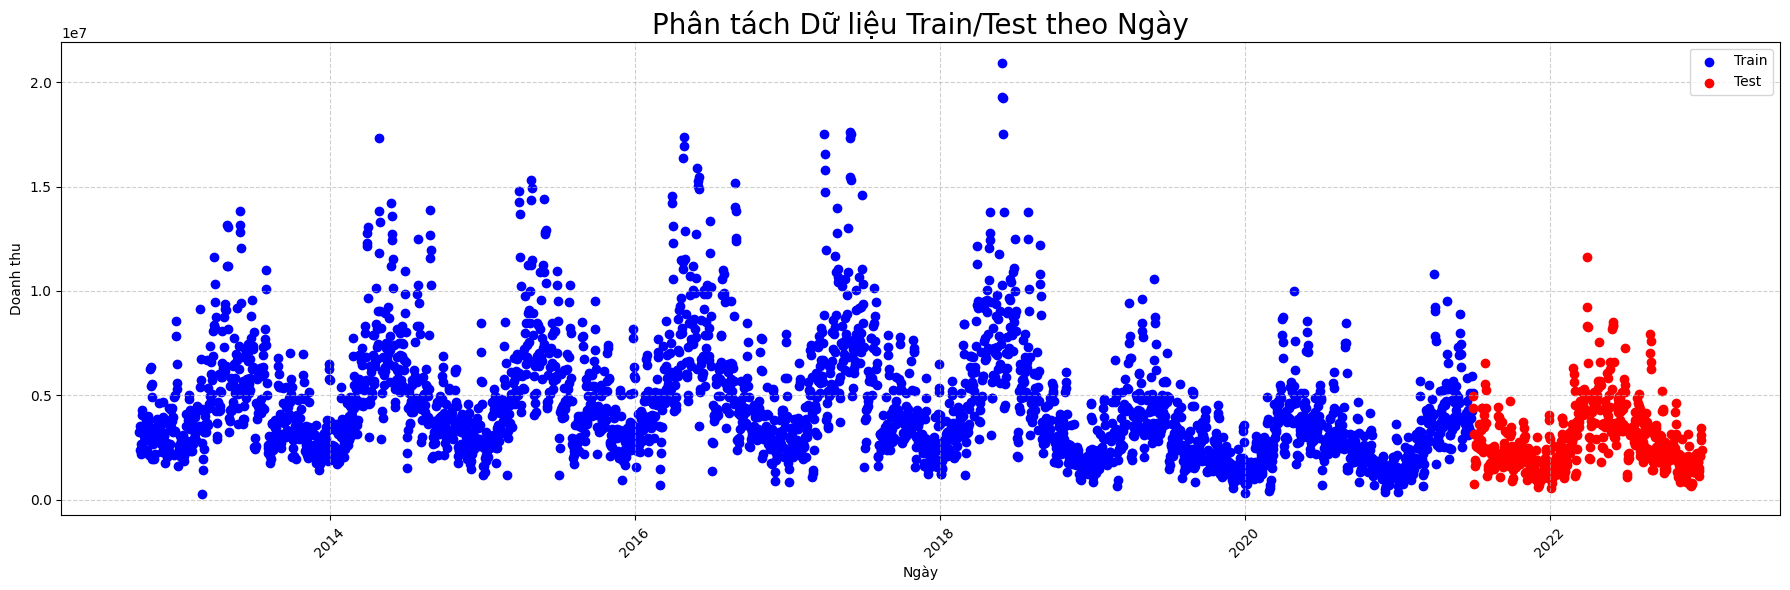

In [9]:
plt.figure(figsize=(18, 6))
plt.scatter(train_data.index, train_data['Revenue'], label='Train', color='blue')
plt.scatter(val_data.index, val_data['Revenue'], label='Test', color='red')
plt.title('Phân tách Dữ liệu Train/Test theo Ngày', fontsize=20)
plt.xlabel('Ngày')
plt.ylabel('Doanh thu')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Recursive Forecasting Loop
Vì chúng ta sử dụng Lags để dự báo dài hạn, ta sẽ dùng chiến lược **Recursive Forecast (Dự báo cuốn chiếu)**. Cụ thể ở mỗi bước thời gian (1 ngày), ta lấy dự báo hiện tại làm đầu vào, cập nhật lại biến Lag và Rolling để dùng cho dự báo ngày tiếp theo.

In [10]:
def recursive_forecast(model_rev, model_cogs, df_full, start_date, end_date, features):
    df_pred = df_full.copy()
    dates = pd.date_range(start=start_date, end=end_date)
    
    for d in dates:
        if d not in df_pred.index: continue
            
        # Cập nhật lags
        for lag in [1, 7, 14, 30, 90]:
            prev_d = d - pd.Timedelta(days=lag)
            if prev_d in df_pred.index:
                df_pred.loc[d, f'Revenue_Lag_{lag}'] = df_pred.loc[prev_d, 'Revenue']
                df_pred.loc[d, f'COGS_Lag_{lag}'] = df_pred.loc[prev_d, 'COGS']
                
        # Cập nhật rollings
        for w in [7, 30]:
            start_w = d - pd.Timedelta(days=w)
            end_w = d - pd.Timedelta(days=1)
            
            slice_rev = df_pred.loc[start_w:end_w, 'Revenue']
            slice_cogs = df_pred.loc[start_w:end_w, 'COGS']
            
            if len(slice_rev) > 0:
                df_pred.loc[d, f'Revenue_Roll_Mean_{w}'] = slice_rev.mean()
                df_pred.loc[d, f'Revenue_Roll_Std_{w}'] = slice_rev.std()
                df_pred.loc[d, f'Revenue_Roll_Max_{w}'] = slice_rev.max()
                df_pred.loc[d, f'Revenue_Roll_Min_{w}'] = slice_rev.min()
                
            if len(slice_cogs) > 0:
                df_pred.loc[d, f'COGS_Roll_Mean_{w}'] = slice_cogs.mean()
                df_pred.loc[d, f'COGS_Roll_Std_{w}'] = slice_cogs.std()
                df_pred.loc[d, f'COGS_Roll_Max_{w}'] = slice_cogs.max()
                df_pred.loc[d, f'COGS_Roll_Min_{w}'] = slice_cogs.min()
                
        # Thực hiện predict
        row = df_pred.loc[[d], features].fillna(0)
        
        rev_pred = model_rev.predict(row)[0]
        cogs_pred = model_cogs.predict(row)[0]
        
        df_pred.loc[d, 'Revenue'] = rev_pred
        df_pred.loc[d, 'COGS'] = cogs_pred
        
    return df_pred.loc[start_date:end_date, ['Revenue', 'COGS']]


## Bước 3: Modeling & Đánh giá metrics
Thử nghiệm các mô hình Tabular Kings: XGBoost, LightGBM, CatBoost

In [17]:
models = {
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=300, learning_rate=0.05, random_state=42, verbose=0)
}

results = []

for name, model_cls in models.items():
    print(f"--- Training {name} ---")
    model_rev = model_cls
    model_rev.fit(X_train, y_train_rev)
    
    if name == 'XGBoost':
        model_cogs = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
    elif name == 'LightGBM':
        model_cogs = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
    else:
        model_cogs = CatBoostRegressor(iterations=300, learning_rate=0.05, random_state=42, verbose=0)
        
    model_cogs.fit(X_train, y_train_cogs)
    
    print(f"Evaluating {name} on Validation Set (Recursive 1.5 Years)...")
    val_preds = recursive_forecast(model_rev, model_cogs, df[df.index <= '2022-12-31'], '2021-07-01', '2022-12-31', features)
    
    mae_rev = mean_absolute_error(val_data['Revenue'], val_preds['Revenue'])
    rmse_rev = mean_squared_error(val_data['Revenue'], val_preds['Revenue'])
    r2_rev = r2_score(val_data['Revenue'], val_preds['Revenue'])
    
    mae_cogs = mean_absolute_error(val_data['COGS'], val_preds['COGS'])
    rmse_cogs = mean_squared_error(val_data['COGS'], val_preds['COGS'])
    r2_cogs = r2_score(val_data['COGS'], val_preds['COGS'])
    
    results.append({
        'Model': name,
        'MAE_Rev': mae_rev, 'RMSE_Rev': rmse_rev, 'R2_Rev': r2_rev,
        'MAE_COGS': mae_cogs, 'RMSE_COGS': rmse_cogs, 'R2_COGS': r2_cogs
    })

res_df = pd.DataFrame(results)
display(res_df)


--- Training XGBoost ---
Evaluating XGBoost on Validation Set (Recursive 1.5 Years)...
--- Training LightGBM ---


  File "c:\Users\Mario\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Mario\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Mario\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mario\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
            

Evaluating LightGBM on Validation Set (Recursive 1.5 Years)...
--- Training CatBoost ---
Evaluating CatBoost on Validation Set (Recursive 1.5 Years)...


,Model,MAE_Rev,RMSE_Rev,R2_Rev,MAE_COGS,RMSE_COGS,R2_COGS
0,XGBoost,4.833026e+06,2.858117e+13,-10.832446,4.536204e+06,2.440532e+13,-12.004054
1,LightGBM,3.508527e+06,1.945437e+13,-7.053999,3.293679e+06,1.518755e+13,-7.092487
2,CatBoost,3.903316e+06,1.803352e+13,-6.465776,3.223198e+06,1.274881e+13,-5.793033


## LSTM 


In [11]:
!pip install pytorch_forecasting pytorch_lightning tensorflow


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_lightning import Trainer
from torch import nn
import torch
import pandas as pd
import numpy as np

# Existing Tree Models
models = {
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=300, learning_rate=0.05, random_state=42, verbose=0)
}

results = []

# TREE MODELS
for name, model_cls in models.items():
    print(f"--- Training {name} ---")

    model_rev = model_cls
    model_rev.fit(X_train, y_train_rev)

    if name == 'XGBoost':
        model_cogs = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
    elif name == 'LightGBM':
        model_cogs = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
    else:
        model_cogs = CatBoostRegressor(iterations=300, learning_rate=0.05, random_state=42, verbose=0)

    model_cogs.fit(X_train, y_train_cogs)

    val_preds = recursive_forecast(
        model_rev, model_cogs,
        df[df.index <= '2022-12-31'],
        '2021-07-01', '2022-12-31',
        features
    )

    results.append({
        'Model': name,
        'MAE_Rev': mean_absolute_error(val_data['Revenue'], val_preds['Revenue']),
        'RMSE_Rev': mean_squared_error(val_data['Revenue'], val_preds['Revenue']),
        'R2_Rev': r2_score(val_data['Revenue'], val_preds['Revenue']),
        'MAE_COGS': mean_absolute_error(val_data['COGS'], val_preds['COGS']),
        'RMSE_COGS': mean_squared_error(val_data['COGS'], val_preds['COGS']),
        'R2_COGS': r2_score(val_data['COGS'], val_preds['COGS'])
    })

# LSTM MODEL
print("---- Training LSTM ----")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val_lstm = X_val.values.reshape((X_val.shape[0], 1, X_val.shape[1]))

lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(1, X_train.shape[1])),
    Dense(32, activation='relu'),
    Dense(2)
])

lstm.compile(optimizer='adam', loss='mse')
lstm.fit(
    X_train_lstm,
    np.column_stack([y_train_rev, y_train_cogs]),
    epochs=30,
    batch_size=32,
    verbose=0
)

preds = lstm.predict(X_val_lstm)

results.append({
    'Model': 'LSTM',
    'MAE_Rev': mean_absolute_error(y_val_rev, preds[:,0]),
    'RMSE_Rev': mean_squared_error(y_val_rev, preds[:,0]),
    'R2_Rev': r2_score(y_val_rev, preds[:,0]),
    'MAE_COGS': mean_absolute_error(y_val_cogs, preds[:,1]),
    'RMSE_COGS': mean_squared_error(y_val_cogs, preds[:,1]),
    'R2_COGS': r2_score(y_val_cogs, preds[:,1])
})

res_df = pd.DataFrame(results)
display(res_df.sort_values("RMSE_Rev"))

--- Training XGBoost ---
--- Training LightGBM ---
--- Training CatBoost ---
---- Training LSTM ----
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


,Model,MAE_Rev,RMSE_Rev,R2_Rev,MAE_COGS,RMSE_COGS,R2_COGS
3,LSTM,5.566743e+05,6.378385e+11,0.735938,5.027398e+05,5.365775e+11,0.714092
2,CatBoost,3.903316e+06,1.803352e+13,-6.465776,3.223198e+06,1.274881e+13,-5.793033
1,LightGBM,3.508527e+06,1.945437e+13,-7.053999,3.293679e+06,1.518755e+13,-7.092487
0,XGBoost,4.833026e+06,2.858117e+13,-10.832446,4.536204e+06,2.440532e+13,-12.004054


In [38]:
preds[:, 0].shape

(549,)

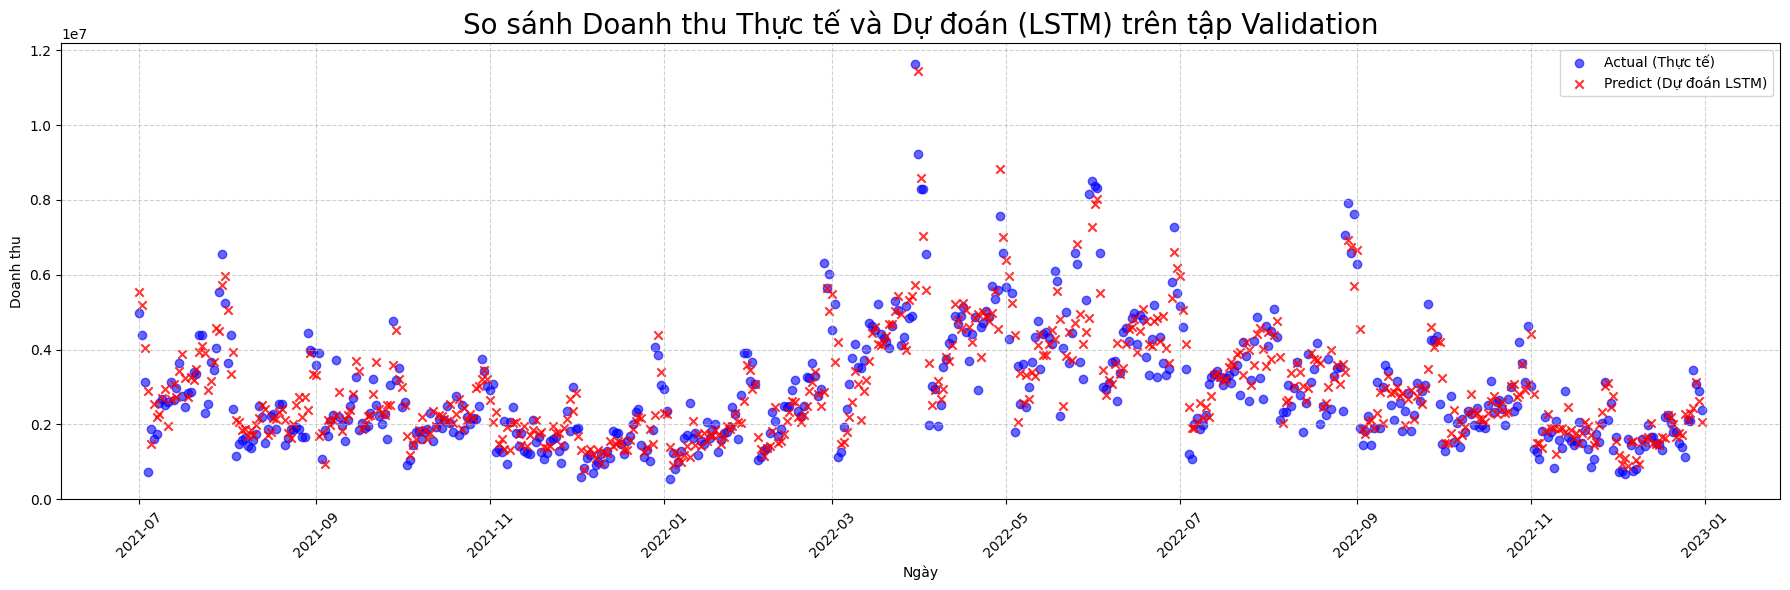

In [29]:
plt.figure(figsize=(18, 6))
# Vẽ Actual (Thực tế) từ tập Validation
plt.scatter(val_data.index, val_data['Revenue'], label='Actual (Thực tế)', color='blue', alpha=0.6)
# Vẽ Predict (Dự đoán) từ model LSTM
plt.scatter(val_data.index, preds[:, 0], label='Predict (Dự đoán LSTM)', color='red', marker='x', alpha=0.8)
plt.title('So sánh Doanh thu Thực tế và Dự đoán (LSTM) trên tập Validation', fontsize=20)
plt.xlabel('Ngày')
plt.ylabel('Doanh thu')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Tối ưu best model

## 5. Final Submission
Sử dụng mô hình tốt nhất để dự báo trực tiếp cho tập Test.

In [47]:
print("---- 1. Chuẩn bị Full Data (Train + Val) cho LSTM Cơ Bản ----")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import os

# Gộp Train và Val
full_train = df[df.index <= '2022-12-31'].copy()
full_train.dropna(subset=features, inplace=True)
test_data = df[df.index >= '2023-01-01'].copy()

# Xử lý nhanh các giá trị NaN trên tập test (do có thể thiếu các biến Lag tương lai)
test_data[features] = test_data[features].ffill().fillna(0)

# Reshape dữ liệu cho LSTM cơ bản: (số_mẫu, 1_timestep, số_features)
X_full_train_lstm = full_train[features].values.reshape((full_train.shape[0], 1, len(features)))
Y_full_train_lstm = np.column_stack([full_train['Revenue'], full_train['COGS']])

print("---- 2. Huấn luyện lại model LSTM cơ bản trên toàn bộ dữ liệu ----")
lstm_basic = Sequential([
    LSTM(64, activation='relu', input_shape=(1, len(features))),
    Dense(32, activation='relu'),
    Dense(2)
])

lstm_basic.compile(optimizer='adam', loss='mse')

# Huấn luyện mô hình (verbose=1 để xem tiến trình)
lstm_basic.fit(
    X_full_train_lstm, 
    Y_full_train_lstm, 
    epochs=30, 
    batch_size=32, 
    verbose=1
)

print("---- 3. Dự báo tập Test ----")
# Reshape tập test để đưa vào mô hình dự báo
X_test_lstm = test_data[features].values.reshape((test_data.shape[0], 1, len(features)))

# Chạy dự báo
final_preds_basic = lstm_basic.predict(X_test_lstm)

print("---- 4. Định dạng lại và lưu file Submit ----")
submission_basic_lstm = pd.DataFrame({
    'Date': test_data.index,
    'Revenue': final_preds_basic[:, 0],
    'COGS': final_preds_basic[:, 1]
})

# Đảm bảo thư mục lưu trữ tồn tại
os.makedirs('../outputs/submissions', exist_ok=True)
submission_basic_lstm.to_csv('../outputs/submissions/basic_lstm_submission.csv', index=False)
print("Thành công! Đã lưu file tại: ../outputs/submissions/basic_lstm_submission.csv")


---- 1. Chuẩn bị Full Data (Train + Val) cho LSTM Cơ Bản ----
---- 2. Huấn luyện lại model LSTM cơ bản trên toàn bộ dữ liệu ----
Epoch 1/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4296680144896.0000  
Epoch 2/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1911589568512.0000  
Epoch 3/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - loss: 1615427796992.0000
Epoch 4/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - loss: 1453194084352.0000
Epoch 5/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1343985156096.0000  
Epoch 6/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1331585351680.0000  
Epoch 7/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1286766723072.0000
Epoch 8/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1248662650880.0000  
Epoch 9/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1219149299712.0000  
Epoch 10/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1198997635072.0000  
Epoch 11/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1

In [32]:
print("---- 1. Chuẩn bị Full Data (Train + Val) ----")
# Gộp Train và Val
full_train = df[df.index <= '2022-12-31'].copy()
full_train.dropna(subset=features, inplace=True)
test_data = df[df.index >= '2023-01-01'].copy()

# Fit lại Scaler trên toàn bộ Full Train
scaler_X_full = MinMaxScaler()
scaler_y_full = MinMaxScaler()

X_full_train_scaled = scaler_X_full.fit_transform(full_train[features])
y_full_train_combined = np.column_stack([full_train['Revenue'], full_train['COGS']])
y_full_train_scaled = scaler_y_full.fit_transform(y_full_train_combined)

# Tạo sequences cho Full Train
X_full_seq, y_full_seq = create_sequences(X_full_train_scaled, y_full_train_scaled, TIME_STEPS)

print("---- 2. Huấn luyện lại mô hình Tối ưu trên Full Train ----")
lstm_final = Sequential([
    LSTM(128, activation='relu', return_sequences=True, input_shape=(TIME_STEPS, X_full_seq.shape[2])),
    Dropout(0.2),
    LSTM(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(2)
])
lstm_final.compile(optimizer='adam', loss='mse')

# Huấn luyện (Có thể lấy đúng số epochs mà early_stop trước đó đã dừng, ví dụ: 40)
lstm_final.fit(X_full_seq, y_full_seq, epochs=40, batch_size=64, verbose=1)

print("---- 3. Tạo Sequence cho Tập Test và Dự báo ----")
# Lấy 30 ngày cuối của Train làm cửa sổ đà (context) cho ngày Test đầu tiên
context_data = full_train.iloc[-TIME_STEPS:].copy()

# Ghép context này vào TRƯỚC test_data
test_combined = pd.concat([context_data, test_data])

# Xử lý các giá trị NaN (các cột Lag trên tập test bị thiếu) bằng cách đẩy dữ liệu cũ tới (ffill)
test_combined[features] = test_combined[features].ffill().fillna(0)

# Scale dữ liệu Test
X_test_combined_scaled = scaler_X_full.transform(test_combined[features])

# Hàm tạo sequences dành riêng cho Test (chỉ trích xuất mảng X, không có mảng y)
def create_test_sequences(X, time_steps=30):
    Xs = []
    # Chỉ lặp đúng bằng số lượng mẫu của tập Test
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
    return np.array(Xs)

X_test_seq = create_test_sequences(X_test_combined_scaled, TIME_STEPS)

# Chạy mô hình dự báo
preds_test_scaled = lstm_final.predict(X_test_seq)

# Đảo ngược Scaling để lấy giá trị thật
preds_test_real = scaler_y_full.inverse_transform(preds_test_scaled)

print("---- 4. Lưu file Submit ----")
submission_opt_lstm = pd.DataFrame({
    'Date': test_data.index,
    'Revenue': preds_test_real[:, 0],
    'COGS': preds_test_real[:, 1]
})

import os
os.makedirs('../outputs/submissions', exist_ok=True)
submission_opt_lstm.to_csv('../outputs/submissions/optimized_lstm_submission.csv', index=False)
print("Thành công! Đã lưu file tại: ../outputs/submissions/optimized_lstm_submission.csv")


---- 1. Chuẩn bị Full Data (Train + Val) ----
---- 2. Huấn luyện lại mô hình Tối ưu trên Full Train ----
Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0136
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0100
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0088
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0080
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0093
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0075
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0072
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0074
Epoch 9/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0068
Epoch 10/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0064
Epoch 11/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0061
Epoch 12/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0065
Epoch 13/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0055
Epoch 14/40
59/59 ━━━━━━━━━━━━━━━

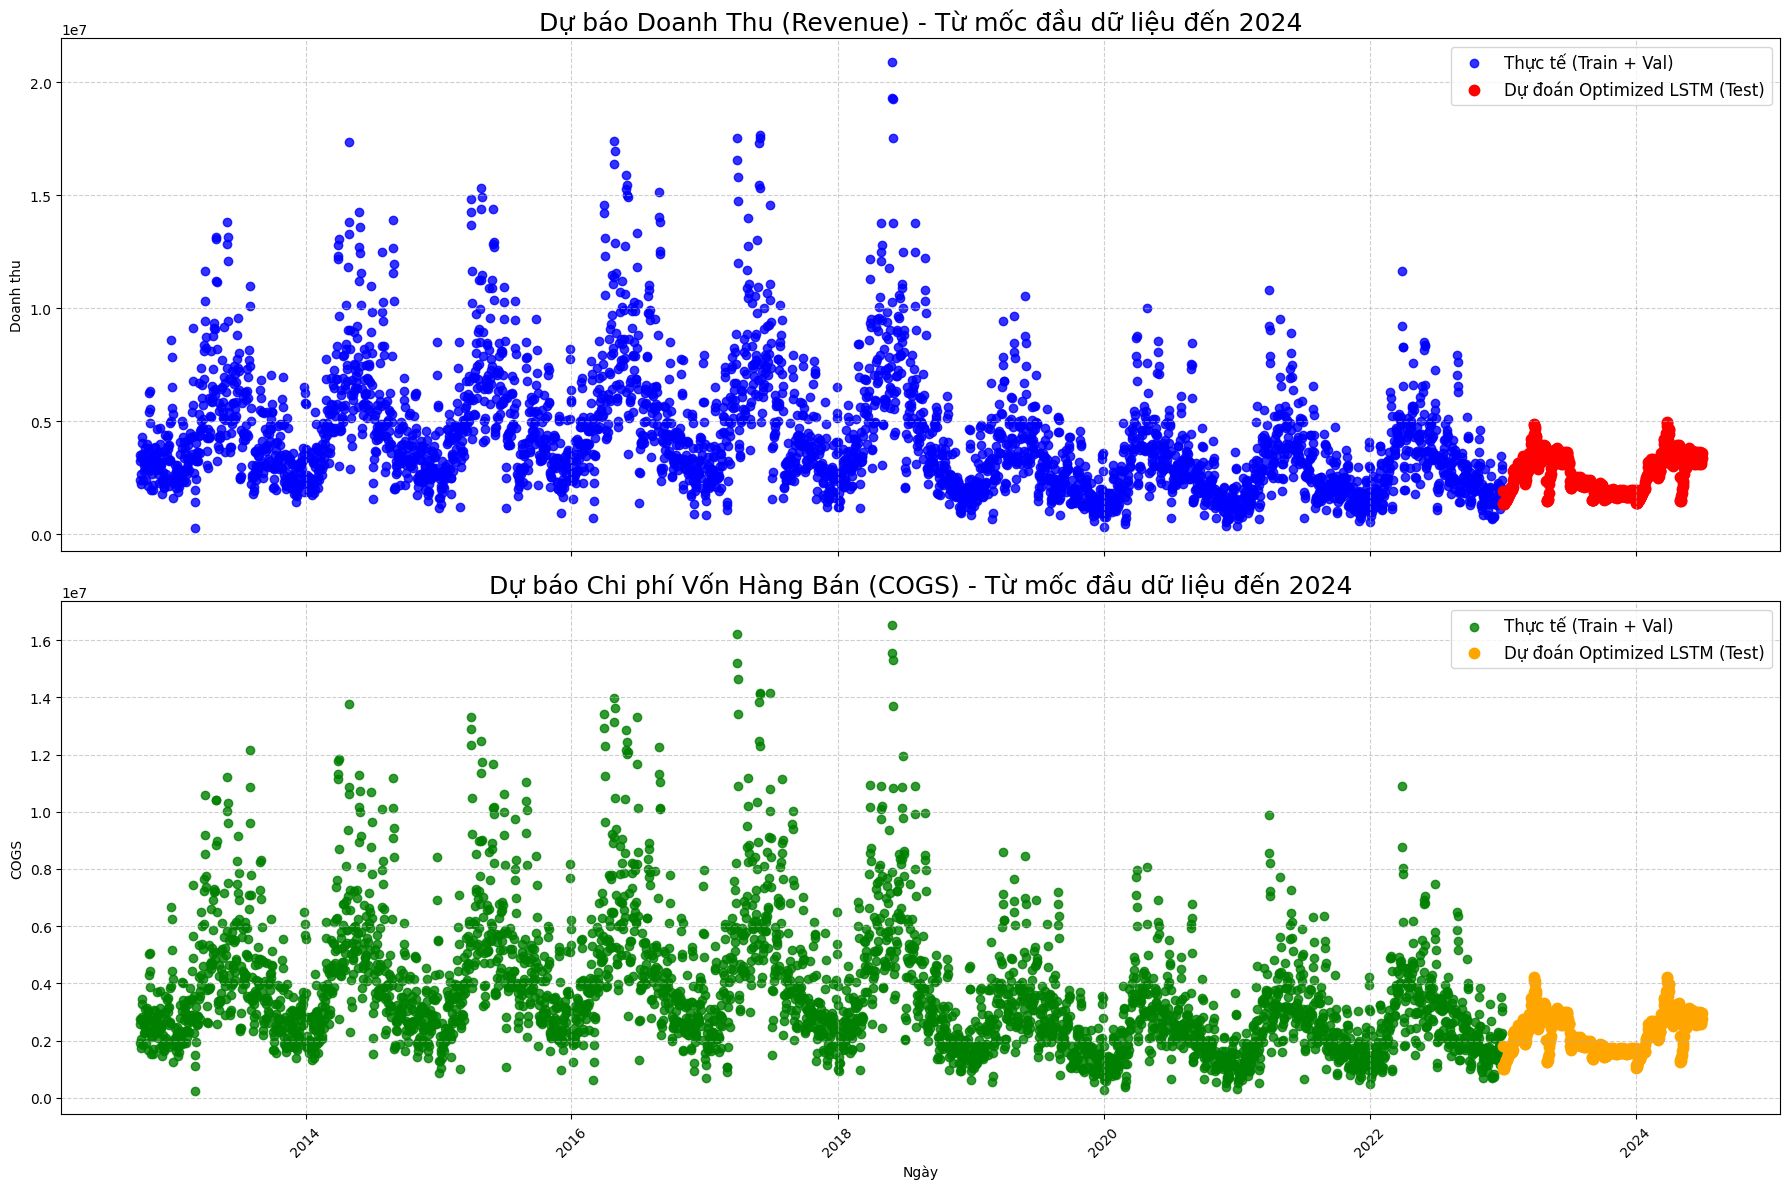

In [50]:
import matplotlib.pyplot as plt

# Tạo hình vẽ với 2 biểu đồ con (trên/dưới) dùng chung trục thời gian X
fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# ================= Biểu đồ 1: Doanh Thu (Revenue) =================
# Vẽ Revenue thực tế (từ đầu đến hết năm 2022)
axes[0].scatter(full_train.index, full_train['Revenue'], label='Thực tế (Train + Val)', color='blue', alpha=0.8)
# Vẽ Revenue dự đoán (từ 2023 đến 2024)
axes[0].scatter(submission_opt_lstm['Date'], submission_opt_lstm['Revenue'], label='Dự đoán Optimized LSTM (Test)', color='red', linewidth=2.5)

axes[0].set_title('Dự báo Doanh Thu (Revenue) - Từ mốc đầu dữ liệu đến 2024', fontsize=18)
axes[0].set_ylabel('Doanh thu')
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# ================= Biểu đồ 2: Giá vốn hàng bán (COGS) =================
# Vẽ COGS thực tế
axes[1].scatter(full_train.index, full_train['COGS'], label='Thực tế (Train + Val)', color='green', alpha=0.8)
# Vẽ COGS dự đoán
axes[1].scatter(submission_opt_lstm['Date'], submission_opt_lstm['COGS'], label='Dự đoán Optimized LSTM (Test)', color='orange', linewidth=2.5)

axes[1].set_title('Dự báo Chi phí Vốn Hàng Bán (COGS) - Từ mốc đầu dữ liệu đến 2024', fontsize=18)
axes[1].set_xlabel('Ngày')
axes[1].set_ylabel('COGS')
axes[1].legend(fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Chỉnh nghiêng chữ ở trục X (ngày tháng) cho dễ đọc
plt.xticks(rotation=45)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()


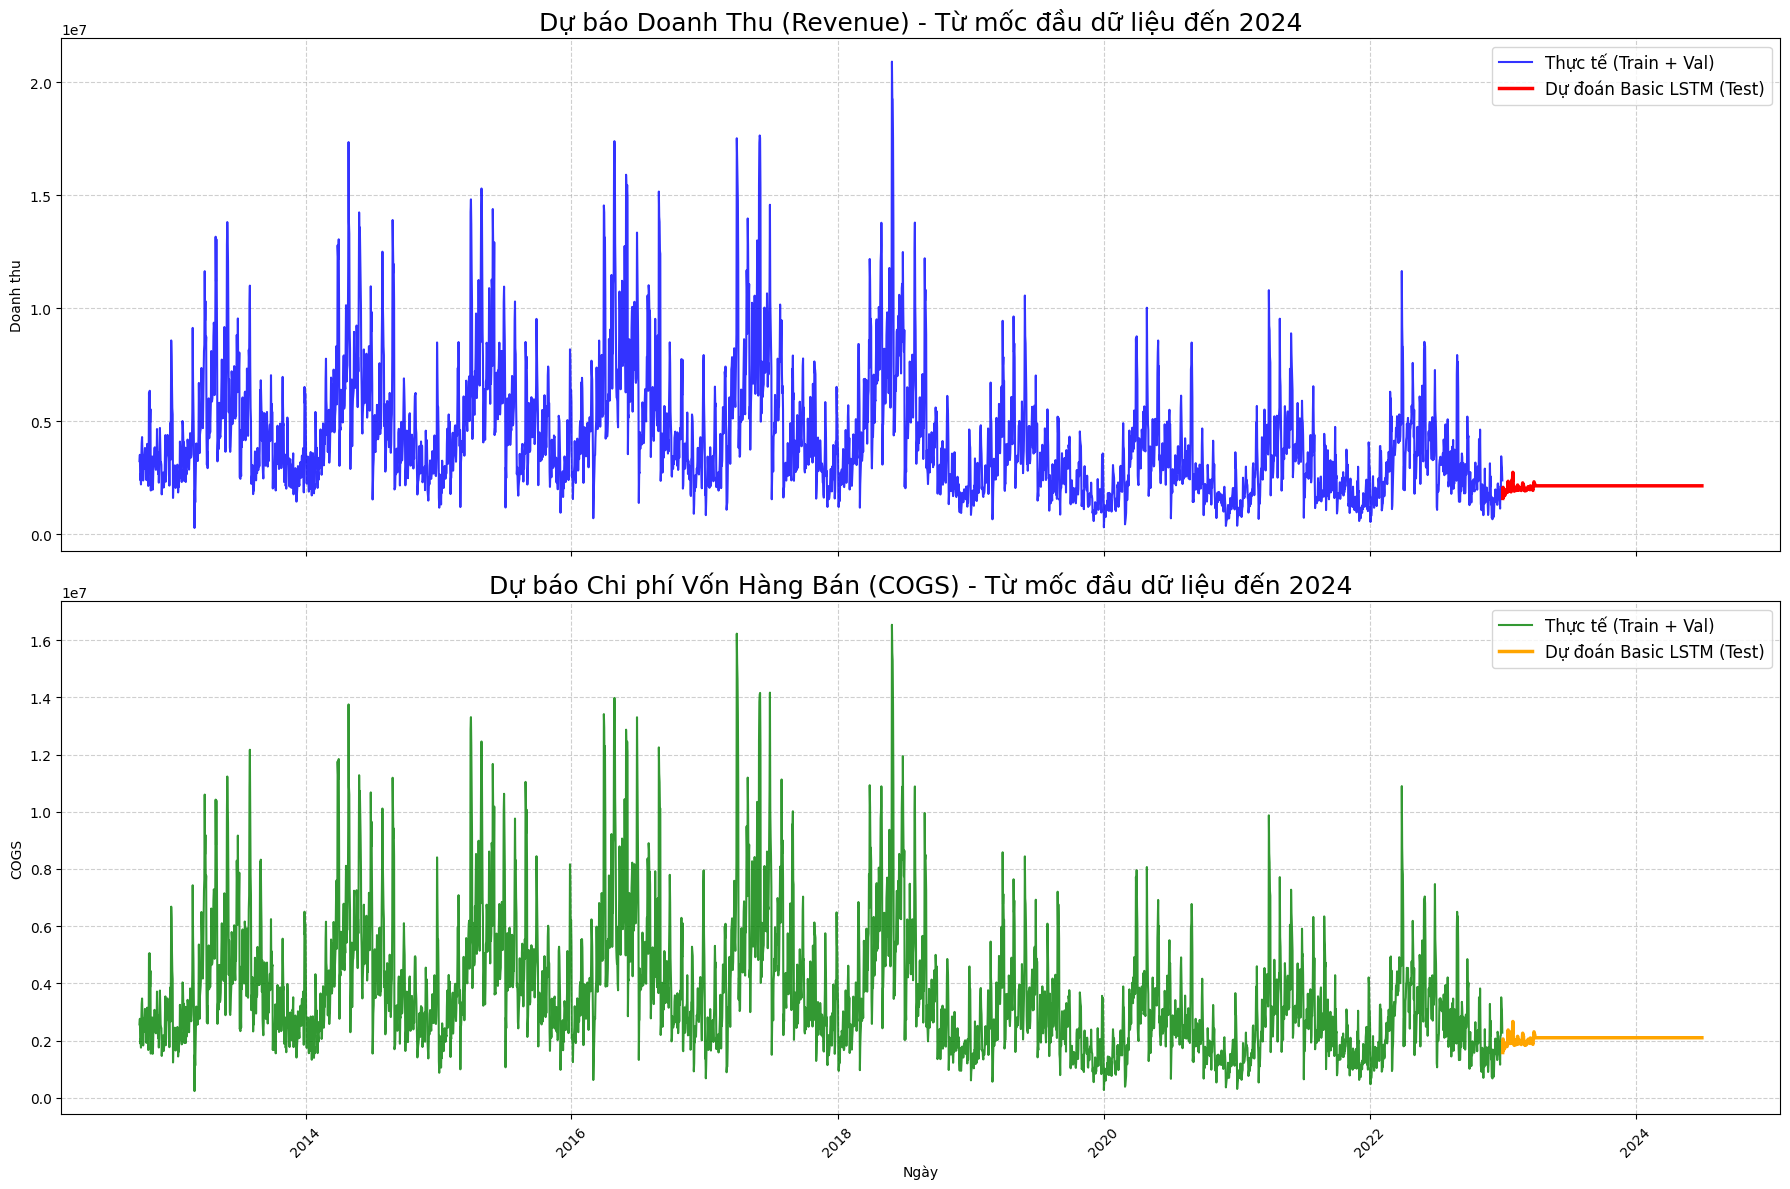

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

# ================= Biểu đồ 1: Doanh Thu (Revenue) =================
# Vẽ Revenue thực tế (từ đầu đến hết năm 2022)
axes[0].plot(full_train.index, full_train['Revenue'], label='Thực tế (Train + Val)', color='blue', alpha=0.8)
# Vẽ Revenue dự đoán (từ 2023 đến 2024)
axes[0].plot(submission_basic_lstm['Date'], submission_basic_lstm['Revenue'], label='Dự đoán Basic LSTM (Test)', color='red', linewidth=2.5)

axes[0].set_title('Dự báo Doanh Thu (Revenue) - Từ mốc đầu dữ liệu đến 2024', fontsize=18)
axes[0].set_ylabel('Doanh thu')
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# ================= Biểu đồ 2: Giá vốn hàng bán (COGS) =================
# Vẽ COGS thực tế
axes[1].plot(full_train.index, full_train['COGS'], label='Thực tế (Train + Val)', color='green', alpha=0.8)
# Vẽ COGS dự đoán
axes[1].plot(submission_basic_lstm['Date'], submission_basic_lstm['COGS'], label='Dự đoán Basic LSTM (Test)', color='orange', linewidth=2.5)

axes[1].set_title('Dự báo Chi phí Vốn Hàng Bán (COGS) - Từ mốc đầu dữ liệu đến 2024', fontsize=18)
axes[1].set_xlabel('Ngày')
axes[1].set_ylabel('COGS')
axes[1].legend(fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Chỉnh nghiêng chữ ở trục X (ngày tháng) cho dễ đọc
plt.xticks(rotation=45)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()


## 5. Thử nghiệm mô hình Temporal Fusion Transformer (TFT)
Mô hình TFT (Temporal Fusion Transformer) phù hợp cho bài toán Time-Series dự báo nhiều bước (multi-horizon) với khả năng xử lý cả dữ liệu tĩnh và chuỗi thời gian.

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



========== TRAIN TFT FOR Revenue ==========


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    160 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  4.4 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.0 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 23.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 377                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    160 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  4.4 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.0 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 23.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 377                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

COGS MAE  : 0.12
COGS RMSE : 0.12
COGS R2   : -66408278789049424.0000

========== FINAL RESULT ==========
    Target    MAE      RMSE            R2
0  Revenue  0.255  0.265801 -3.258156e+17
1     COGS  0.120  0.120000 -6.640828e+16


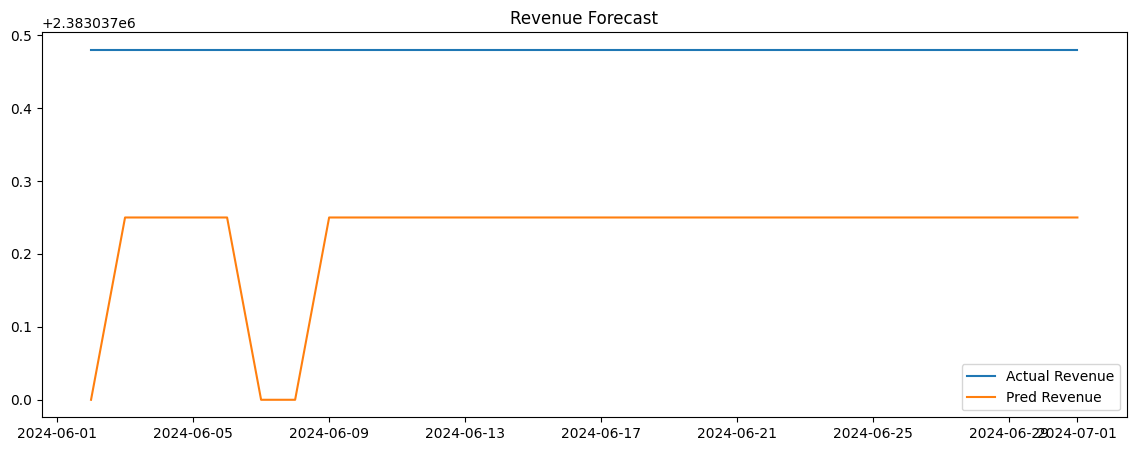

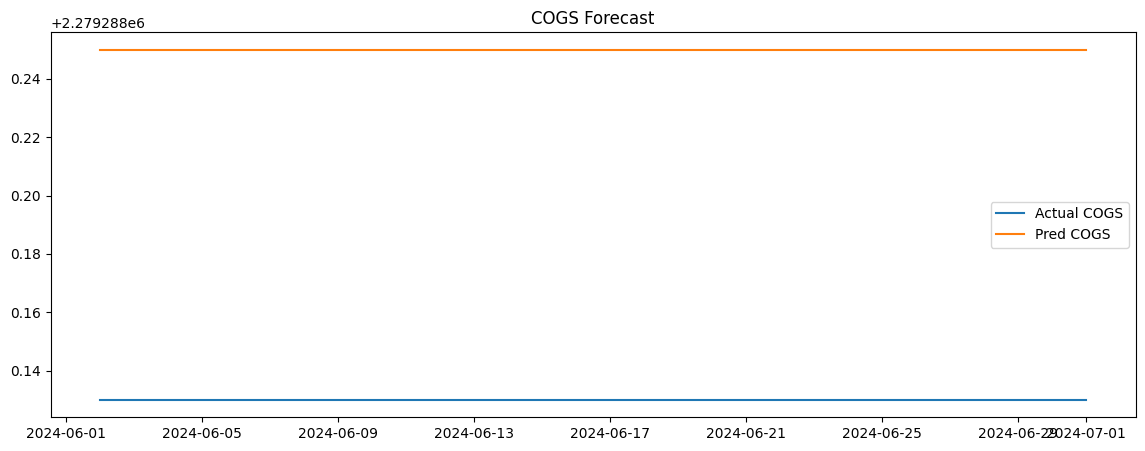

In [24]:
# import pandas as # import numpy as np
# import torch
# import pytorch_lightning as pl

# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# from pytorch_forecasting import (
#     TemporalFusionTransformer,
#     TimeSeriesDataSet
# )

# from pytorch_forecasting.metrics import QuantileLoss
# from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor

import pandas as pd
import numpy as np
import torch

import lightning.pytorch as pl

from lightning.pytorch.callbacks import (
    EarlyStopping,
    LearningRateMonitor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from pytorch_forecasting import (
    TemporalFusionTransformer,
    TimeSeriesDataSet
)

from pytorch_forecasting.metrics import QuantileLoss

# df là dataframe gốc của bạn
# cần có index datetime hoặc cột Date

df_tft = df.copy().reset_index()

# Nếu tên cột ngày là index -> đổi tên
if "index" in df_tft.columns:
    df_tft.rename(columns={"index": "Date"}, inplace=True)

df_tft["Date"] = pd.to_datetime(df_tft["Date"])
df_tft = df_tft.sort_values("Date").reset_index(drop=True)

# Tạo feature thời gian
df_tft["Month"] = df_tft["Date"].dt.month
df_tft["DayOfWeek"] = df_tft["Date"].dt.dayofweek
df_tft["Is_Weekend"] = (df_tft["DayOfWeek"] >= 5).astype(int)

# time index liên tục
df_tft["time_idx"] = np.arange(len(df_tft))

# 1 nhóm duy nhất
df_tft["group_id"] = "all_sales"


df_tft["Revenue"] = df_tft["Revenue"].replace([np.inf, -np.inf], np.nan)
df_tft["COGS"]    = df_tft["COGS"].replace([np.inf, -np.inf], np.nan)

# Fill missing theo time series
df_tft["Revenue"] = df_tft["Revenue"].ffill().bfill()
df_tft["COGS"]    = df_tft["COGS"].ffill().bfill()

# ==========================================================
# 2. TRAIN / VALID SPLIT TIME SERIES
# ==========================================================

max_prediction_length = 30
max_encoder_length = 90

train_boundary = df_tft["time_idx"].max() - max_prediction_length

train_df = df_tft[df_tft.time_idx <= train_boundary]
val_df   = df_tft[df_tft.time_idx > train_boundary]

# ==========================================================
# FUNCTION TRAIN TFT
# ==========================================================

def run_tft(target_col):

    print(f"\n========== TRAIN TFT FOR {target_col} ==========")

    training = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target=target_col,
        group_ids=["group_id"],

        min_encoder_length=max_encoder_length // 2,
        max_encoder_length=max_encoder_length,

        min_prediction_length=1,
        max_prediction_length=max_prediction_length,

        static_categoricals=[],

        time_varying_known_reals=[
            "time_idx",
            "Month",
            "DayOfWeek",
            "Is_Weekend"
        ],

        time_varying_unknown_reals=[
            "Revenue",
            "COGS"
        ],

        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    validation = TimeSeriesDataSet.from_dataset(
        training,
        df_tft,
        predict=True,
        stop_randomization=True
    )

    train_loader = training.to_dataloader(
        train=True,
        batch_size=32,
        num_workers=0
    )

    val_loader = validation.to_dataloader(
        train=False,
        batch_size=32,
        num_workers=0
    )

    # callbacks
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        min_delta=1e-4,
        mode="min"
    )

    lr_logger = LearningRateMonitor()

    trainer = pl.Trainer(
        max_epochs=20,
        accelerator="auto",
        gradient_clip_val=0.1,
        callbacks=[early_stop, lr_logger],
        enable_model_summary=True
    )

    model = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=0.03,
        hidden_size=16,
        attention_head_size=2,
        dropout=0.1,
        hidden_continuous_size=8,
        loss=QuantileLoss(),
        output_size=7,
        reduce_on_plateau_patience=4,
    )

    trainer.fit(
        model,
        train_dataloaders=train_loader,
        val_dataloaders=val_loader
    )

    # ======================================================
    # Predict
    # ======================================================

    preds = model.predict(val_loader).numpy().flatten()

    y_true = val_df[target_col].values

    # chỉ lấy đúng số điểm validation cuối cùng
    preds = preds[-len(y_true):]

    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    print(f"{target_col} MAE  : {mae:.2f}")
    print(f"{target_col} RMSE : {rmse:.2f}")
    print(f"{target_col} R2   : {r2:.4f}")

    return model, preds, {
        "Target": target_col,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# ==========================================================
# RUN 2 MODELS
# ==========================================================

results = []

model_rev, preds_rev, metrics_rev = run_tft("Revenue")
results.append(metrics_rev)

model_cogs, preds_cogs, metrics_cogs = run_tft("COGS")
results.append(metrics_cogs)

# ==========================================================
# RESULT TABLE
# ==========================================================

results_df = pd.DataFrame(results)
print("\n========== FINAL RESULT ==========")
print(results_df)

# ==========================================================
# OPTIONAL PLOT
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(val_df["Date"], val_df["Revenue"], label="Actual Revenue")
plt.plot(val_df["Date"], preds_rev, label="Pred Revenue")
plt.title("Revenue Forecast")
plt.legend()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(val_df["Date"], val_df["COGS"], label="Actual COGS")
plt.plot(val_df["Date"], preds_cogs, label="Pred COGS")
plt.title("COGS Forecast")
plt.legend()
plt.show()